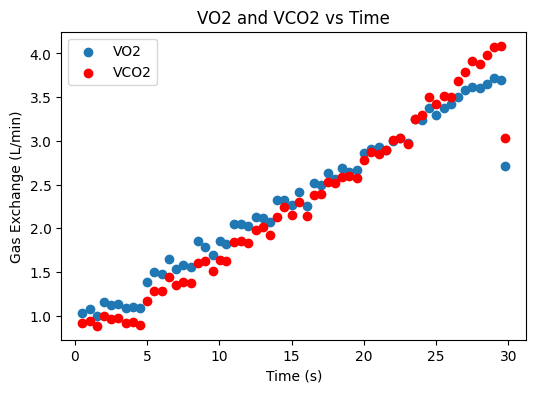

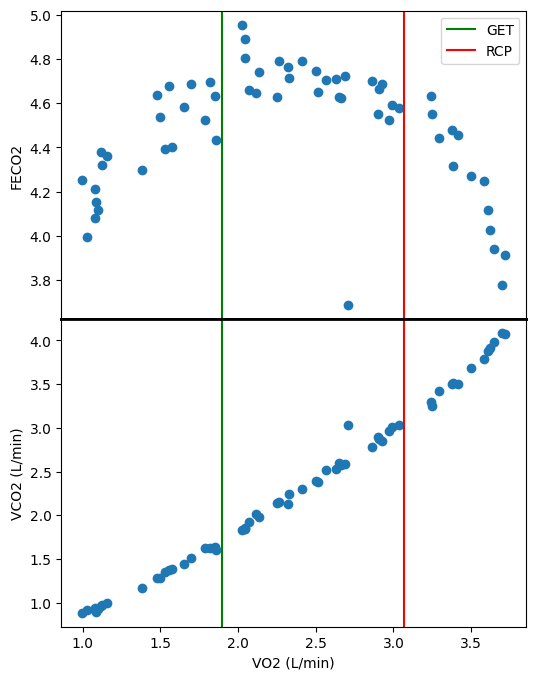

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('/kaggle/input/demo-knes381/subject_1432.csv')
                

df['TIME'] = pd.to_numeric(df['TIME'], errors='coerce')
df['VO2'] = pd.to_numeric(df['VO2'], errors='coerce')
df['VCO2'] = pd.to_numeric(df['VCO2'], errors='coerce')


df = df.dropna(subset=['TIME', 'VO2'])

df = df.dropna(subset=['TIME', 'VO2', 'VCO2'])

df.columns = df.columns.str.strip()

df['TIME'] = pd.to_numeric(df['TIME'], errors='coerce')
df['VO2'] = pd.to_numeric(df['VO2'], errors='coerce')
df['FECO2'] = pd.to_numeric(df['FECO2'], errors='coerce')


# --- Main VO2/VCO2 plot ---
plt.figure(figsize=(6,4))

plt.scatter(df['TIME'], df['VO2'], label='VO2')
plt.scatter(df['TIME'], df['VCO2'], label='VCO2', color='red')

plt.xlabel('Time (s)')
plt.ylabel('Gas Exchange (L/min)')
plt.title('VO2 and VCO2 vs Time')
plt.legend()
plt.show()

get_vo2 = 1.9
rcp_vo2 = 3.07
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6,8), sharex=True)

ax1.scatter(df['VO2'], df['FECO2'])
ax1.axvline(get_vo2, color='green', label='GET')
ax1.axvline(rcp_vo2, color='red', label='RCP')
ax1.set_ylabel('FECO2')
ax1.legend()
ax1.tick_params(labelbottom=False)

ax2.scatter(df['VO2'], df['VCO2'])
ax2.axvline(get_vo2, color='green')
ax2.axvline(rcp_vo2, color='red')
ax2.set_xlabel('VO2 (L/min)')
ax2.set_ylabel('VCO2 (L/min)')

plt.subplots_adjust(hspace=0)
ax1.spines['bottom'].set_linewidth(2)
ax2.spines['top'].set_linewidth(2)
plt.show()